<a href="https://colab.research.google.com/github/nicholastimmann-cyber/Travel_Tide_CustomerSegmentation/blob/main/clusteranalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cluster Analysis

In [ ]:
directory = "/content/drive/MyDrive/Colab Notebooks"

# Load base user data
df_user = pd.read_csv(f'{directory}/user_base.csv')

# Load segmentation results
seg90 = pd.read_csv(f'{directory}/user_segment_0.90.csv')
seg93 = pd.read_csv(f'{directory}/user_segment_0.93.csv')
seg95 = pd.read_csv(f'{directory}/user_segment_0.95.csv')

# Merge user data with each segmentation
df1 = pd.merge(df_user, seg93, on='user_id')   # PCA 0.93
df2 = pd.merge(df_user, seg90, on='user_id')   # PCA 0.90
df3 = pd.merge(df_user, seg95, on='user_id')   # PCA 0.95

# Check results
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("df3 shape:", df3.shape)

print(df1.head())
print(df2.head())
print(df3.head())

df1 shape: (5998, 34)
df2 shape: (5998, 34)
df3 shape: (5998, 34)
   user_id  num_sessions  avg_session_duration  std_session_duration  \
0    23557             8                76.625             68.783174   
1    94883             8                67.750             70.241929   
2   101486             8               122.250             55.943211   
3   101961             8               117.750             59.796679   
4   106907             8               241.500            274.650427   

   avg_clicks  bookings  canceled_trips  num_trips  destinations  \
0      10.250         2             0.0        2.0           0.0   
1       9.125         2             0.0        2.0           2.0   
2      16.375         2             0.0        2.0           1.0   
3      15.750         5             0.0        5.0           5.0   
4      30.000         1             1.0        NaN           NaN   

   avg_checked_bags  ...  summer  spring  fall  winter  gender  married  \
0               N

In [ ]:
df_user.groupby('gender').size()

,0
gender,
F,5292
M,695
O,11


In [ ]:
#wir entfernen features die wir nicht analysieren wollen
columns=["user_id"]
df1.drop(columns=columns, inplace=True)

#booleans in int umwandeln -> gut für heatmaps

# convert binary categoricals
df1["gender"] = df1["gender"].map({"F": 0, "M": 1, "O":2})
df1["married"] = df1["married"].astype(int)
df1["has_children"] = df1["has_children"].astype(int)

df1["home_country"] = (df1["home_country"] == 'canada').astype(int)

df1.head()

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,summer,spring,fall,winter,gender,married,has_children,home_country,age,group
0,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,0,1,0,0,67.260274,2
1,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.0,2.0,0.0,0.0,0,1,0,0,53.980822,3
2,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,2.0,0.0,0.0,0.0,0,1,1,0,53.252055,3
3,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,1.0,3.0,0.0,1.0,0,1,0,0,45.476712,5
4,8,241.500,274.650427,30.000,1,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,1,0,47.304110,4


In [ ]:
df1.groupby('group').size()

,0
group,
0,108
1,847
2,436
3,2481
4,519
5,1607


In [ ]:
pd.crosstab(df1["group"],df1["gender"])

gender,0,1,2
group,,,
0,98,10,0
1,754,91,2
2,384,52,0
3,2176,301,4
4,442,76,1
5,1438,165,4


In [ ]:
pd.crosstab(df1["group"],[df1["gender"],df1["has_children"]])

gender           0         1       2   
has_children     0    1    0    1  0  1
group                                  
0               59   39    6    4  0  0
1              505  249   51   40  1  1
2              253  131   31   21  0  0
3             1407  769  189  112  1  3
4              297  145   53   23  0  1
5             1061  377  124   41  2  2

In [ ]:
group_summary = df1.groupby("group").median(numeric_only=True).T
print(df1.groupby("group").size().reset_index())
group_summary


   group     0
0      0   108
1      1   847
2      2   436
3      3  2481
4      4   519
5      5  1607


group,0,1,2,3,4,5
num_sessions,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
avg_session_duration,102.250000,83.666667,104.527778,105.375000,246.625000,135.625000
std_session_duration,72.320769,63.398400,71.697569,74.876923,276.350070,81.537021
avg_clicks,13.687500,11.222222,14.111111,14.125000,30.888889,18.250000
bookings,2.000000,0.000000,2.000000,2.000000,3.000000,4.000000
canceled_trips,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
num_trips,2.000000,1.000000,2.000000,2.000000,2.000000,4.000000
destinations,1.000000,0.000000,1.000000,2.000000,2.000000,4.000000
avg_checked_bags,1.000000,0.000000,0.500000,0.500000,0.500000,0.500000
avg_seats,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
group_summary_mean = df1.groupby("group").mean(numeric_only=True).T
group_summary_mean

group,0,1,2,3,4,5
num_sessions,8.212963,8.179457,8.178899,8.189037,8.262042,8.229620
avg_session_duration,107.536754,95.866302,107.223656,108.960049,244.948514,139.643354
std_session_duration,81.875425,87.963157,82.051759,83.727657,268.521238,90.450802
avg_clicks,14.454064,12.531179,14.382709,14.620210,30.956776,18.770229
bookings,2.148148,0.510035,2.488532,2.216445,3.225434,4.466086
canceled_trips,0.018519,0.105077,0.009174,0.000806,0.978805,0.003111
num_trips,2.129630,1.099359,2.479358,2.215639,2.341365,4.462974
destinations,1.796296,0.185897,1.284404,1.906086,1.915663,3.716864
avg_checked_bags,0.931636,0.120690,0.548675,0.586155,0.573527,0.567288
avg_seats,1.770370,1.000000,1.199286,1.163375,1.169397,1.190304


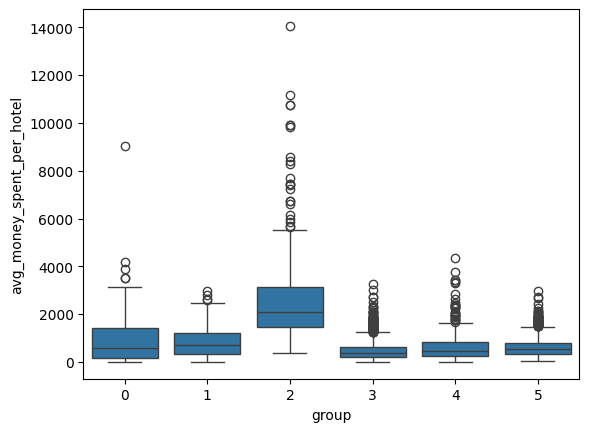

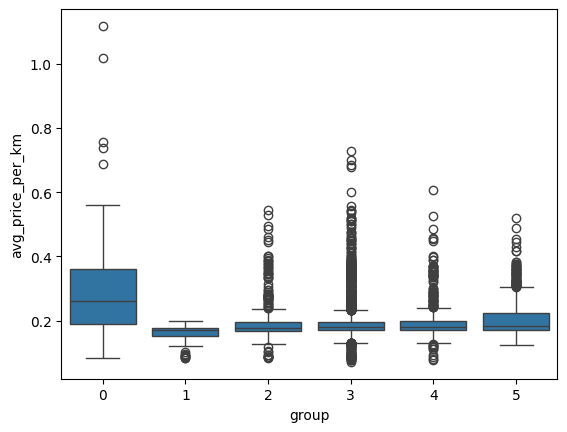

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: distribution of money spent by group
sns.boxplot(x="group", y="avg_money_spent_per_hotel", data=df1)
plt.show()

# Example: average km flown by group
sns.boxplot(x="group", y="avg_price_per_km", data=df1)
plt.show()

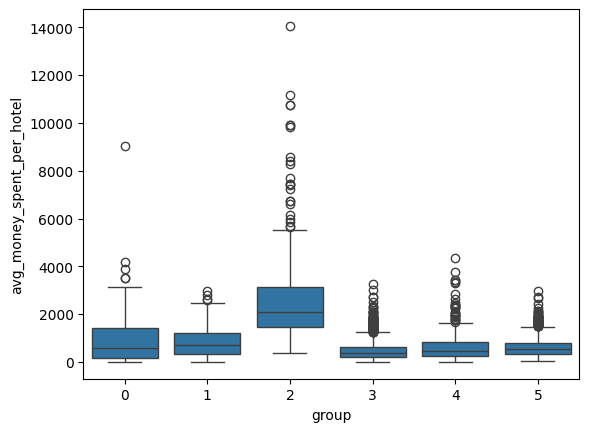

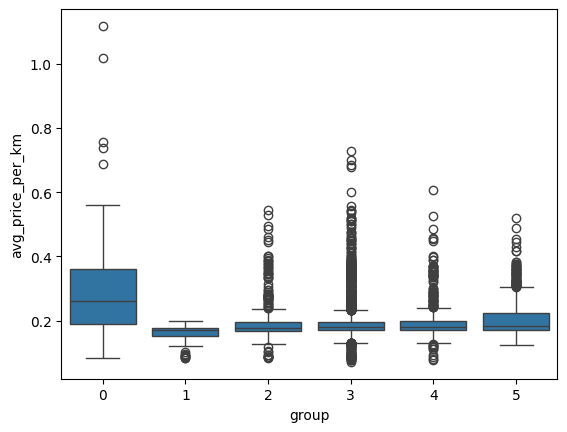

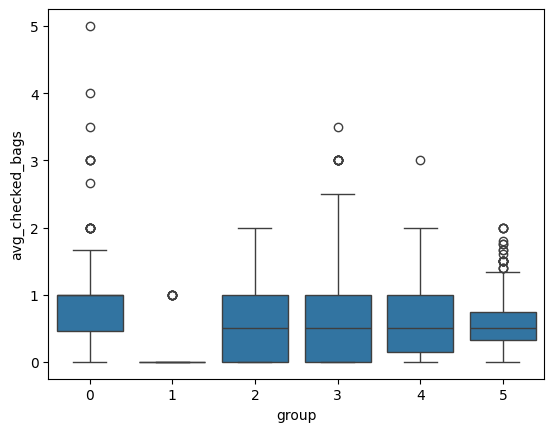

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: distribution of money spent by group
sns.boxplot(x="group", y="avg_money_spent_per_hotel", data=df1)
plt.show()

# Example: average km flown by group
sns.boxplot(x="group", y="avg_price_per_km", data=df1)
plt.show()

# Example: average free checked bags by group
sns.boxplot(x="group", y="avg_checked_bags", data=df1)
plt.show()

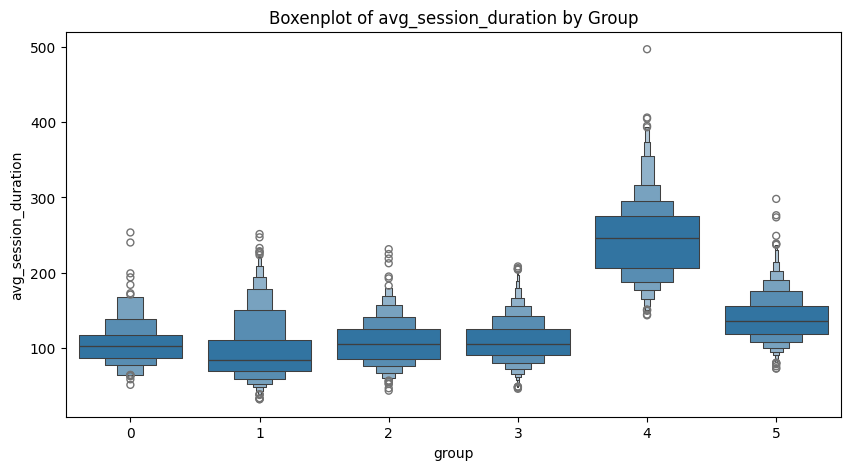

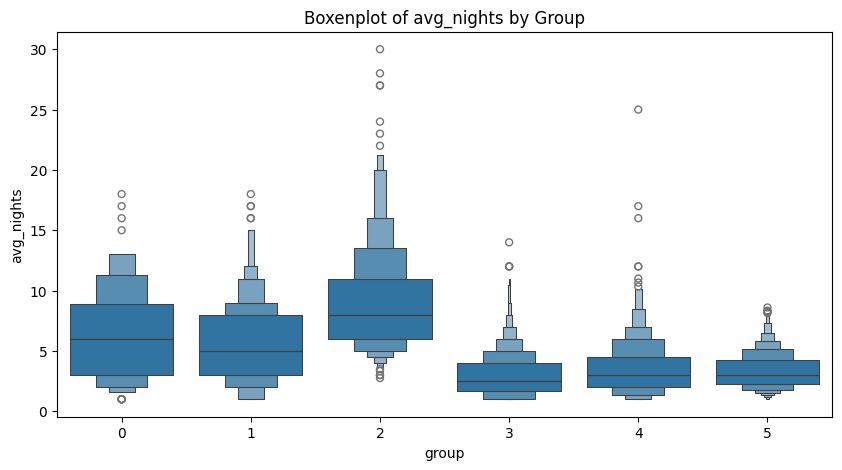

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    "avg_session_duration",
    "avg_nights",
]

for feature in selected_features:
    plt.figure(figsize=(10, 5))
    sns.boxenplot(x="group", y=feature, data=df1)
    plt.title(f"Boxenplot of {feature} by Group")
    plt.show()

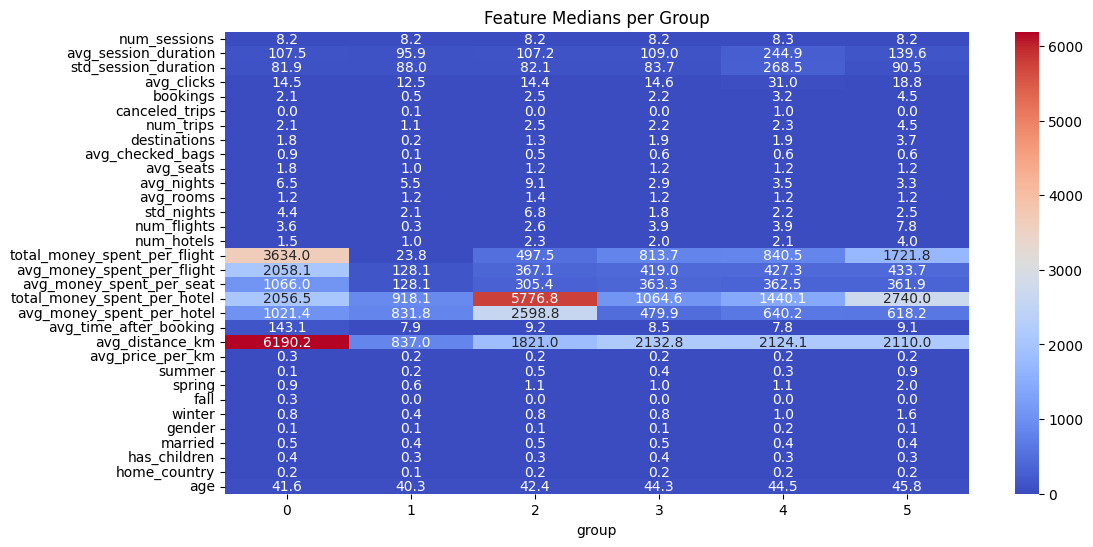

In [ ]:
# Heatmap of group means
plt.figure(figsize=(12, 6))
sns.heatmap(group_summary_mean, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Feature Medians per Group")
plt.show()

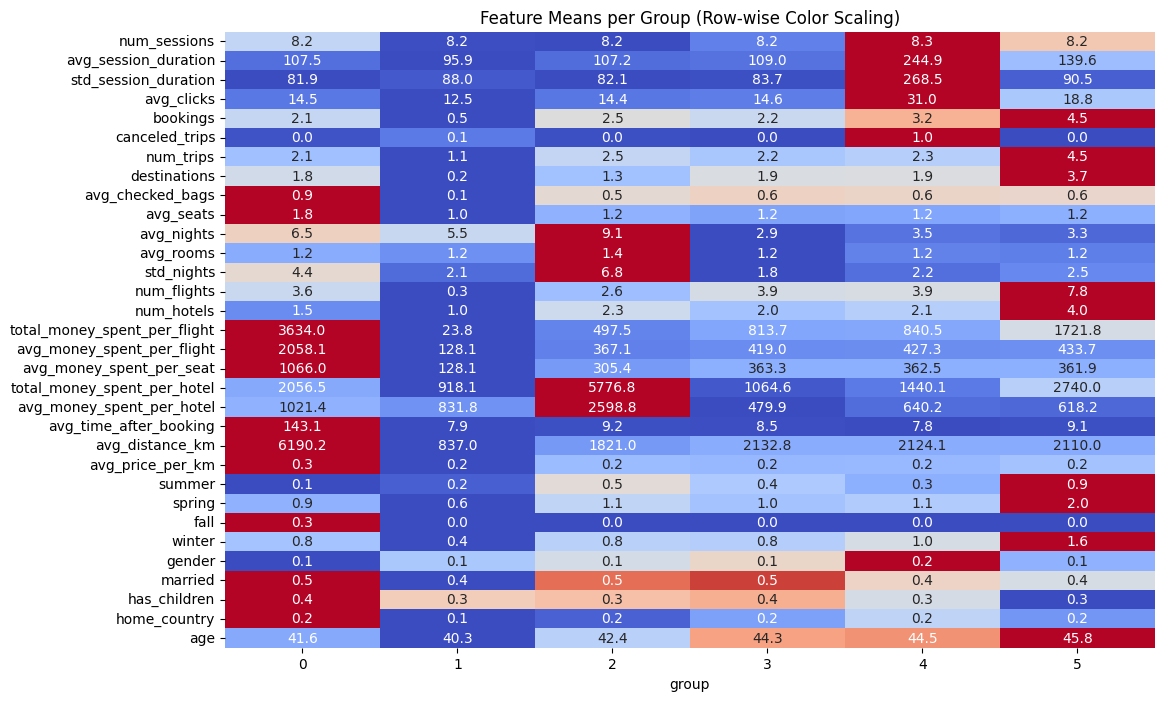

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = group_summary_mean.copy()

# Row-wise Normalisierung nur für Farbe
color_data = data.sub(data.min(axis=1), axis=0)
color_data = color_data.div(data.max(axis=1) - data.min(axis=1), axis=0)

plt.figure(figsize=(12, 8))

sns.heatmap(
    color_data,
    cmap="coolwarm",
    annot=data,          # Originalwerte anzeigen!
    fmt=".1f",
    cbar=False,
    xticklabels=data.columns,
    yticklabels=data.index
)

plt.title("Feature Means per Group (Row-wise Color Scaling)")
plt.show()

Gutscheine: Free Hotel Meal(Group 2), Free Checked Bags(group 3), Free cancelation(Group4), exclusive discount(Group 0), 1 night free + hotel ( Group 5/1)

For 95%

In [ ]:
#wir entfernen features die wir nicht analysieren wollen
columns=["user_id"]
df3.drop(columns=columns, inplace=True)

#booleans in int umwandeln -> gut für heatmaps

# convert binary categoricals
df3["gender"] = df3["gender"].map({"F": 0, "M": 1, "O":2})
df3["married"] = df3["married"].astype(int)
df3["has_children"] = df3["has_children"].astype(int)

df3["home_country"] = (df3["home_country"] == 'canada').astype(int)

df3.head()

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,summer,spring,fall,winter,gender,married,has_children,home_country,age,group
0,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,0,1,0,0,67.260274,1
1,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.0,2.0,0.0,0.0,0,1,0,0,53.980822,3
2,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,2.0,0.0,0.0,0.0,0,1,1,0,53.252055,1
3,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,1.0,3.0,0.0,1.0,0,1,0,0,45.476712,3
4,8,241.500,274.650427,30.000,1,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,1,0,47.304110,2


In [ ]:
df3.groupby('group').size()

,0
group,
0,110
1,2108
2,579
3,3201


In [ ]:
pd.crosstab(df3["group"],df3["gender"])

gender,0,1,2
group,,,
0,100,10,0
1,1851,253,4
2,493,84,2
3,2848,348,5


In [ ]:
pd.crosstab(df3["group"],[df1["gender"],df3["has_children"]])

gender           0         1       2   
has_children     0    1    0    1  0  1
group                                  
0               59   41    6    4  0  0
1             1181  670  145  108  1  3
2              330  163   58   26  0  2
3             2012  836  245  103  3  2

In [ ]:
group_summary = df3.groupby("group").median(numeric_only=True).T
print(df3.groupby("group").size().reset_index())
group_summary

   group     0
0      0   110
1      1  2108
2      2   579
3      3  3201


group,0,1,2,3
num_sessions,8.000000,8.000000,8.000000,8.000000
avg_session_duration,103.687500,91.750000,239.125000,123.625000
std_session_duration,72.320769,67.409609,270.344456,79.818432
avg_clicks,13.875000,12.250000,30.000000,16.625000
bookings,2.000000,1.000000,3.000000,3.000000
canceled_trips,0.000000,0.000000,1.000000,0.000000
num_trips,2.000000,1.000000,2.000000,3.000000
destinations,1.500000,1.000000,2.000000,3.000000
avg_checked_bags,1.000000,0.500000,0.500000,0.500000
avg_seats,1.500000,1.000000,1.000000,1.000000


In [ ]:
group_summary_mean = df3.groupby("group").mean(numeric_only=True).T
group_summary_mean

group,0,1,2,3
num_sessions,8.227273,8.188805,8.252159,8.205561
avg_session_duration,108.412904,96.768109,240.449815,126.927283
std_session_duration,82.553677,79.909645,265.759583,87.523259
avg_clicks,14.573081,12.879174,30.400086,17.055572
bookings,2.190909,1.171252,3.065630,3.628241
canceled_trips,0.018182,0.024668,0.956822,0.000625
num_trips,2.172727,1.505919,2.321293,3.627616
destinations,1.827273,1.055452,1.882129,2.993752
avg_checked_bags,0.929091,0.531175,0.569467,0.586467
avg_seats,1.770000,1.059153,1.178468,1.216563


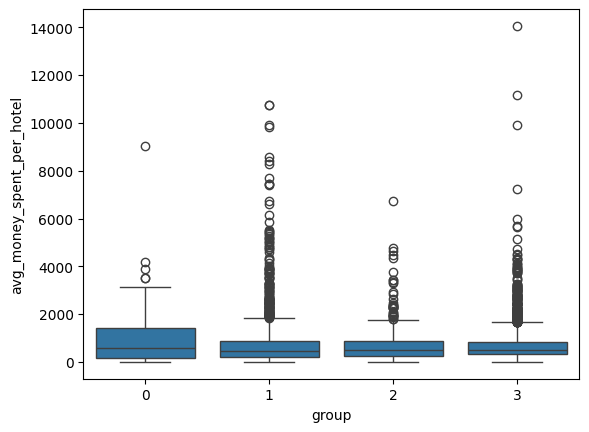

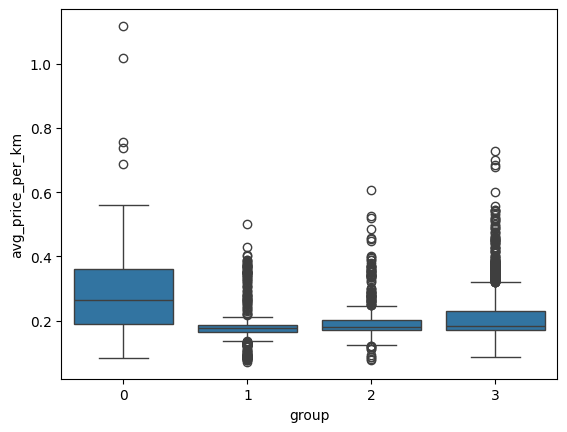

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: distribution of money spent by group
sns.boxplot(x="group", y="avg_money_spent_per_hotel", data=df3)
plt.show()

# Example: average km flown by group
sns.boxplot(x="group", y="avg_price_per_km", data=df3)
plt.show()

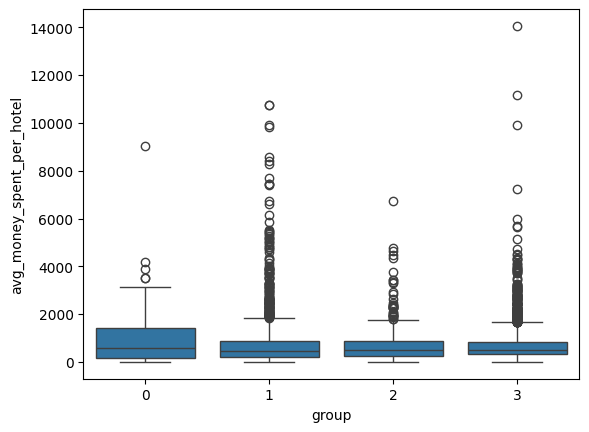

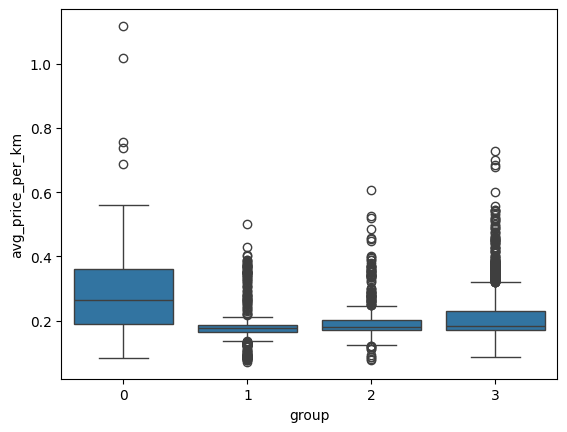

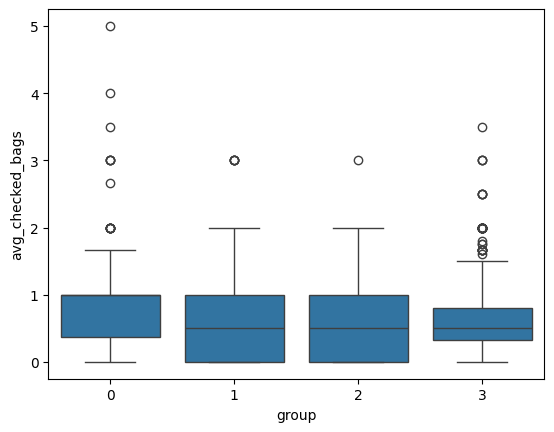

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: distribution of money spent by group
sns.boxplot(x="group", y="avg_money_spent_per_hotel", data=df3)
plt.show()

# Example: average km flown by group
sns.boxplot(x="group", y="avg_price_per_km", data=df3)
plt.show()

# Example: average free checked bags by group
sns.boxplot(x="group", y="avg_checked_bags", data=df3)
plt.show()

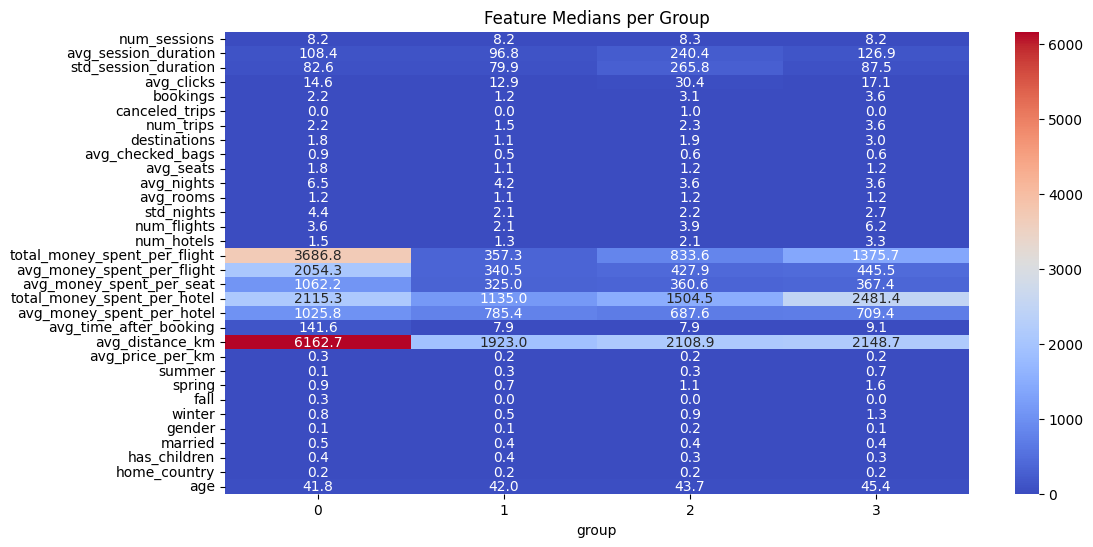

In [ ]:
# Heatmap of group means
plt.figure(figsize=(12, 6))
sns.heatmap(group_summary_mean, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Feature Medians per Group")
plt.show()

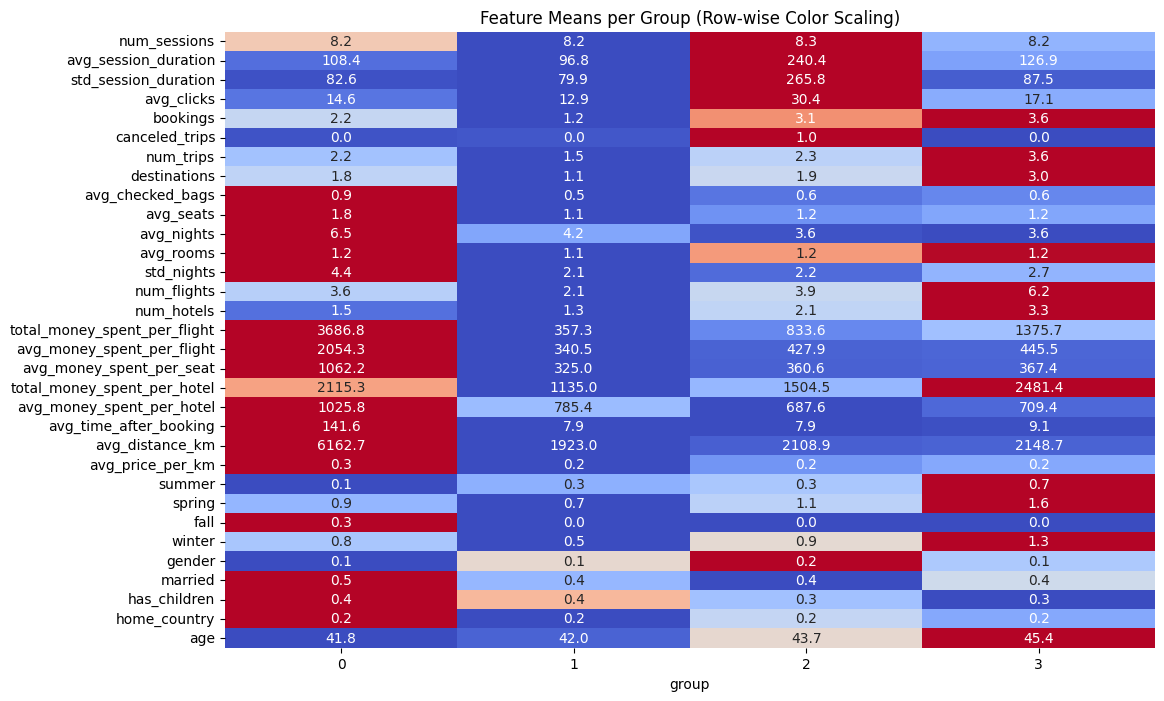

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = group_summary_mean.copy()

# Row-wise Normalisierung nur für Farbe
color_data = data.sub(data.min(axis=1), axis=0)
color_data = color_data.div(data.max(axis=1) - data.min(axis=1), axis=0)

plt.figure(figsize=(12, 8))

sns.heatmap(
    color_data,
    cmap="coolwarm",
    annot=data,          # Originalwerte anzeigen!
    fmt=".1f",
    cbar=False,
    xticklabels=data.columns,
    yticklabels=data.index
)

plt.title("Feature Means per Group (Row-wise Color Scaling)")
plt.show()

For 90%

In [ ]:
#wir entfernen features die wir nicht analysieren wollen
columns=["user_id"]
df2.drop(columns=columns, inplace=True)

#booleans in int umwandeln -> gut für heatmaps

# convert binary categoricals
df2["gender"] = df2["gender"].map({"F": 0, "M": 1, "O":2})
df2["married"] = df2["married"].astype(int)
df2["has_children"] = df2["has_children"].astype(int)

df2["home_country"] = (df2["home_country"] == 'canada').astype(int)

df2.head()

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,summer,spring,fall,winter,gender,married,has_children,home_country,age,group
0,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,0,1,0,0,67.260274,5
1,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.0,2.0,0.0,0.0,0,1,0,0,53.980822,1
2,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,2.0,0.0,0.0,0.0,0,1,1,0,53.252055,1
3,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,1.0,3.0,0.0,1.0,0,1,0,0,45.476712,2
4,8,241.500,274.650427,30.000,1,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,1,0,47.304110,3


In [ ]:
df2.groupby('group').size()

,0
group,
0,98
1,2466
2,1616
3,518
4,844
5,424
6,32


In [ ]:
pd.crosstab(df2["group"],df2["gender"])

gender,0,1,2
group,,,
0,92,6,0
1,2161,301,4
2,1447,165,4
3,440,77,1
4,751,91,2
5,373,51,0
6,28,4,0


In [ ]:
pd.crosstab(df2["group"],[df2["gender"],df2["has_children"]])

gender           0         1       2   
has_children     0    1    0    1  0  1
group                                  
0               56   36    4    2  0  0
1             1396  765  189  112  1  3
2             1068  379  124   41  2  2
3              295  145   54   23  0  1
4              504  247   51   40  1  1
5              244  129   30   21  0  0
6               19    9    2    2  0  0

In [ ]:
group_summary = df2.groupby("group").median(numeric_only=True).T
print(df2.groupby("group").size().reset_index())
group_summary

   group     0
0      0    98
1      1  2466
2      2  1616
3      3   518
4      4   844
5      5   424
6      6    32


group,0,1,2,3,4,5,6
num_sessions,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
avg_session_duration,106.687500,105.187500,135.527778,246.687500,83.666667,104.187500,92.750000
std_session_duration,76.319672,74.816588,81.924508,276.242651,63.477169,71.250055,68.798979
avg_clicks,14.450000,14.125000,18.250000,30.950000,11.173611,14.000000,12.427778
bookings,2.000000,2.000000,4.000000,3.000000,0.000000,2.000000,2.000000
canceled_trips,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
num_trips,2.000000,2.000000,4.000000,2.000000,1.000000,2.000000,2.000000
destinations,2.000000,2.000000,4.000000,2.000000,0.000000,1.000000,2.000000
avg_checked_bags,0.750000,0.500000,0.500000,0.500000,0.000000,0.500000,1.000000
avg_seats,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000


In [ ]:
group_summary_mean = df2.groupby("group").mean(numeric_only=True).T
group_summary_mean

group,0,1,2,3,4,5,6
num_sessions,8.255102,8.188970,8.228960,8.262548,8.176540,8.174528,8.218750
avg_session_duration,110.489569,108.883652,139.553560,245.034081,96.082872,106.777778,102.446181
std_session_duration,84.949096,83.757166,90.484270,268.374610,88.460809,81.365875,71.760062
avg_clicks,14.844048,14.610531,18.757857,30.964414,12.559097,14.321069,13.759809
bookings,2.265306,2.210462,4.452970,3.239382,0.508294,2.459906,2.500000
canceled_trips,0.020408,0.000811,0.002475,0.978764,0.107820,0.009434,0.000000
num_trips,2.244898,2.209651,4.450495,2.346693,1.100977,2.450472,2.500000
destinations,1.846939,1.898621,3.706064,1.917836,0.179153,1.264151,2.125000
avg_checked_bags,0.830782,0.586544,0.563520,0.575305,0.109091,0.553248,1.058333
avg_seats,1.658163,1.161260,1.189440,1.170323,1.000000,1.204207,1.834375


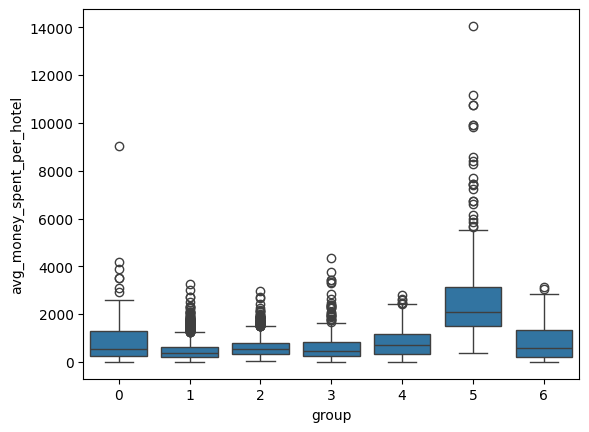

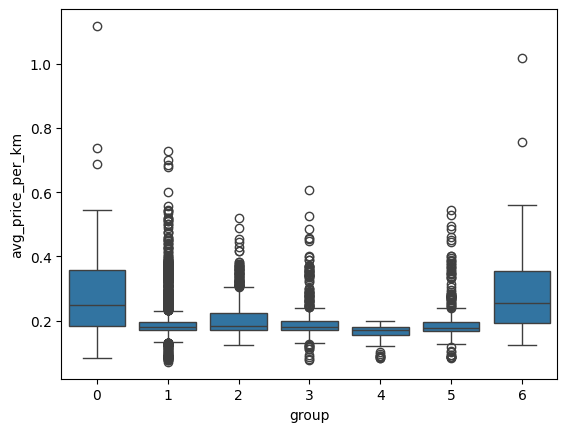

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: distribution of money spent by group
sns.boxplot(x="group", y="avg_money_spent_per_hotel", data=df2)
plt.show()

# Example: average km flown by group
sns.boxplot(x="group", y="avg_price_per_km", data=df2)
plt.show()

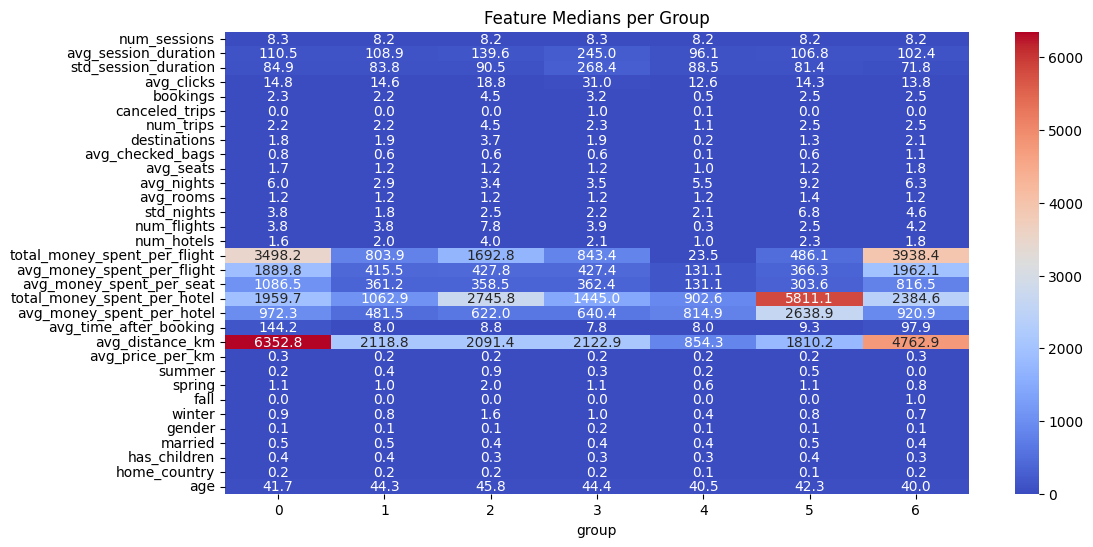

In [ ]:
# Heatmap of group means
plt.figure(figsize=(12, 6))
sns.heatmap(group_summary_mean, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Feature Medians per Group")
plt.show()

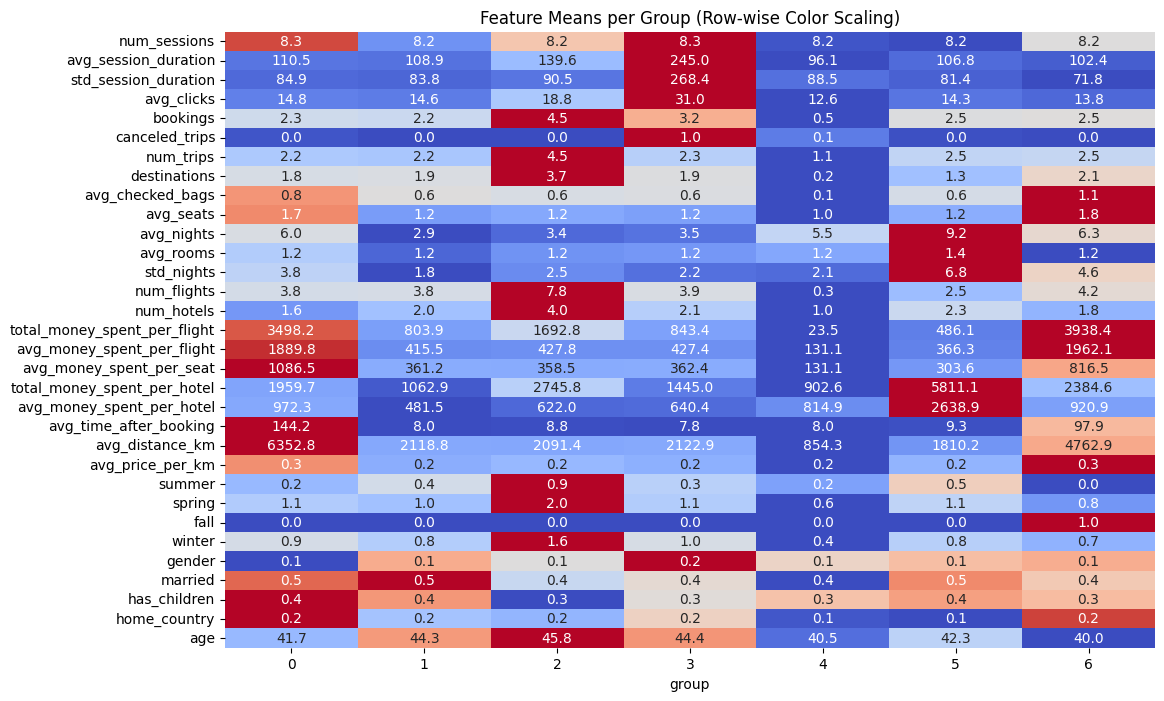

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = group_summary_mean.copy()

# Row-wise Normalisierung nur für Farbe
color_data = data.sub(data.min(axis=1), axis=0)
color_data = color_data.div(data.max(axis=1) - data.min(axis=1), axis=0)

plt.figure(figsize=(12, 8))

sns.heatmap(
    color_data,
    cmap="coolwarm",
    annot=data,          # Originalwerte anzeigen!
    fmt=".1f",
    cbar=False,
    xticklabels=data.columns,
    yticklabels=data.index
)

plt.title("Feature Means per Group (Row-wise Color Scaling)")
plt.show()

After deliberating wether to use:
7 groups 90% var_exp/
6 groups 93% var_exp/
4 groups 95% var_exp

It was decided to use 93% var_exp because there are 5 pre determined vouchers by the company ruling out 95% and when looking at the group sizes for 90% there were two groups with below 100 customers meaning it made most sense to go for 93% var_exp


In [ ]:
#Creation of final csv
df1.head()

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,summer,spring,fall,winter,gender,married,has_children,home_country,age,group
0,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,0,1,0,0,67.260274,2
1,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.0,2.0,0.0,0.0,0,1,0,0,53.980822,3
2,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,2.0,0.0,0.0,0.0,0,1,1,0,53.252055,3
3,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,1.0,3.0,0.0,1.0,0,1,0,0,45.476712,5
4,8,241.500,274.650427,30.000,1,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,1,0,47.304110,4


In [ ]:
#Creation of Final CSV

directory = "/content/drive/MyDrive/Colab Notebooks"

df1.to_csv(f'{directory}/Final.CSV', index=False)